# Gestra — Reproduce Final Report Figures

This notebook regenerates the figures used in the final report and shows the important results directly in the notebook output cells.

The raw personal webcam recordings are not committed in this repository, so this notebook uses the checked-in experiment log plus the final report summary values. It saves every generated figure to both `results/figures/` and `final_site/assets/`.

In [1]:
from pathlib import Path
import json
import shutil
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results" / "figures"
ASSETS_DIR = PROJECT_ROOT / "final_site" / "assets"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

ACTION_NAMES = ["idle", "lpunch", "rpunch", "forward", "backward"]
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
})

def save_report_figure(fig, filename):
    results_path = RESULTS_DIR / filename
    assets_path = ASSETS_DIR / filename
    fig.savefig(results_path)
    fig.savefig(assets_path)
    print(f"Saved: {results_path.relative_to(PROJECT_ROOT)}")
    print(f"Saved: {assets_path.relative_to(PROJECT_ROOT)}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Results figures: {RESULTS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Report assets:    {ASSETS_DIR.relative_to(PROJECT_ROOT)}")

Project root: /Users/been/Desktop/Gestra_final
Results figures: results/figures
Report assets:    final_site/assets


## 1. Dataset Summary

These are the final report dataset counts. The project used 8 recorded `.npz` files and 494 20-frame sliding windows for the reported validation split and figures.

Recordings: 8
Sliding windows: 494


,class,recordings,valid_frames,sliding_windows
0,idle,4,140,167
1,lpunch,1,64,75
2,rpunch,1,68,85
3,forward,1,74,100
4,backward,1,73,67


Saved: results/figures/dataset_summary.png
Saved: final_site/assets/dataset_summary.png


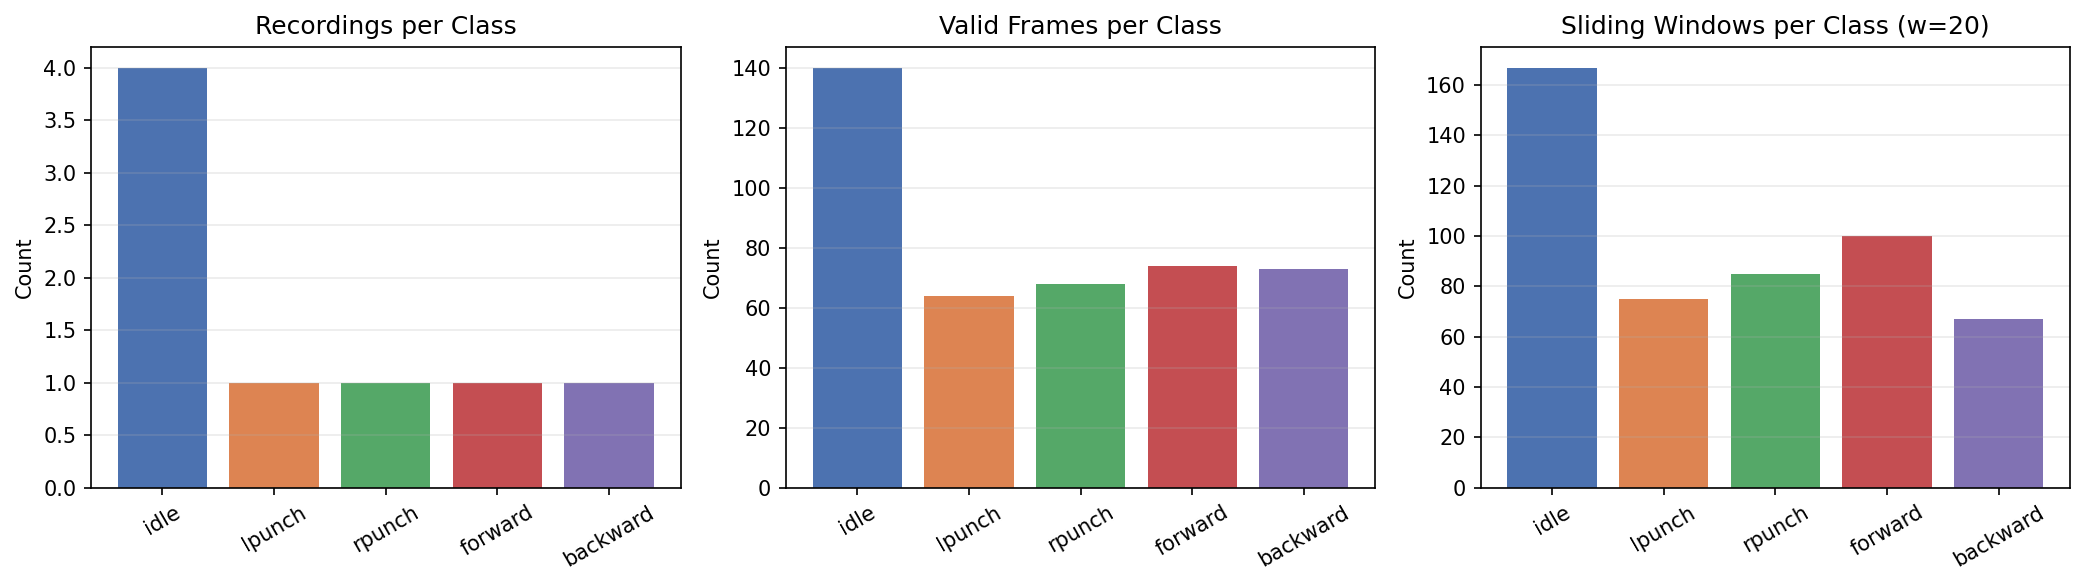

In [2]:
dataset_summary = pd.DataFrame({
    "class": ACTION_NAMES,
    "recordings": [4, 1, 1, 1, 1],
    "valid_frames": [140, 64, 68, 74, 73],
    "sliding_windows": [167, 75, 85, 100, 67],
})

total_recordings = int(dataset_summary["recordings"].sum())
total_windows = int(dataset_summary["sliding_windows"].sum())
print(f"Recordings: {total_recordings}")
print(f"Sliding windows: {total_windows}")
display(dataset_summary)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(dataset_summary["class"], dataset_summary["recordings"], color=COLORS)
axes[0].set_title("Recordings per Class")
axes[0].set_ylabel("Count")

axes[1].bar(dataset_summary["class"], dataset_summary["valid_frames"], color=COLORS)
axes[1].set_title("Valid Frames per Class")
axes[1].set_ylabel("Count")

axes[2].bar(dataset_summary["class"], dataset_summary["sliding_windows"], color=COLORS)
axes[2].set_title("Sliding Windows per Class (w=20)")
axes[2].set_ylabel("Count")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
save_report_figure(fig, "dataset_summary.png")
plt.show()

## 2. Training Curve

The curve comes from the saved LR-A epoch log. The best validation accuracy reaches 100%, but the curve also shows instability, which is why the report treats this as a narrow single-user result instead of a general claim.

Best validation accuracy: 100.00%
First epoch reaching 100% validation accuracy: 24
Final epoch validation accuracy: 95.92%


,epoch,train_acc,val_acc,train_loss
50,51,1.0000,1.0000,0.0018
51,52,0.9949,1.0000,0.0111
52,53,0.9722,0.9694,0.0708
53,54,0.9823,0.8673,0.0448
54,55,0.9899,0.7347,0.0277
55,56,0.9924,0.9898,0.0293
56,57,0.9899,0.9694,0.0237
57,58,0.9975,0.9694,0.0218
58,59,1.0000,1.0000,0.0057
59,60,0.9949,0.9592,0.0128


Saved: results/figures/training_curve.png
Saved: final_site/assets/training_curve.png


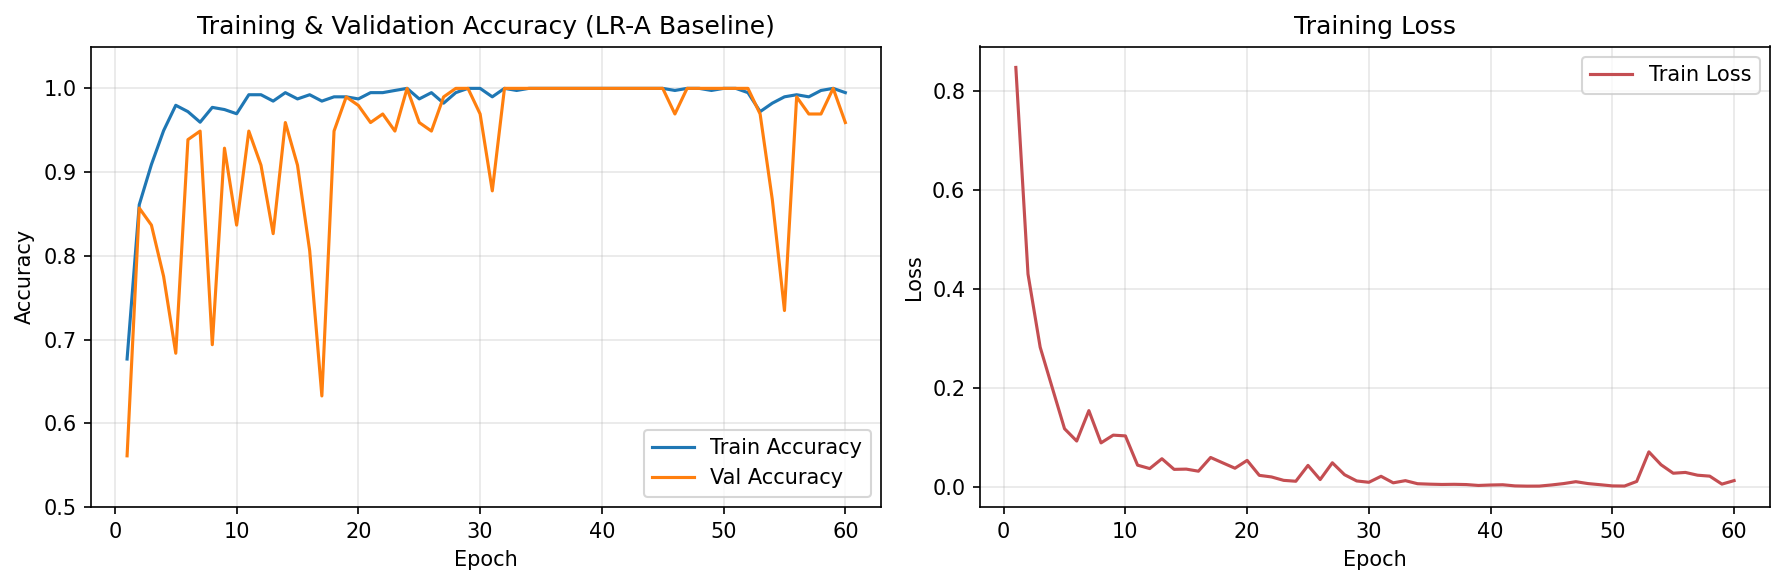

In [3]:
epoch_log_path = PROJECT_ROOT / "motion" / "models" / "epochs_LR-A.json"
with open(epoch_log_path) as f:
    epoch_log = json.load(f)

epoch_df = pd.DataFrame(epoch_log)
first_100 = epoch_df.loc[epoch_df["val_acc"] == 1.0, "epoch"].min()
best_val = epoch_df["val_acc"].max()
last_val = epoch_df.iloc[-1]["val_acc"]
print(f"Best validation accuracy: {best_val:.2%}")
print(f"First epoch reaching 100% validation accuracy: {int(first_100)}")
print(f"Final epoch validation accuracy: {last_val:.2%}")
display(epoch_df.tail(10))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epoch_df["epoch"], epoch_df["train_acc"], label="Train Accuracy", linewidth=1.5)
ax1.plot(epoch_df["epoch"], epoch_df["val_acc"], label="Val Accuracy", linewidth=1.5)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.set_title("Training & Validation Accuracy (LR-A Baseline)")
ax1.set_ylim(0.5, 1.05)
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(epoch_df["epoch"], epoch_df["train_loss"], label="Train Loss", color="#C44E52", linewidth=1.5)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("Training Loss")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
save_report_figure(fig, "training_curve.png")
plt.show()

## 3. Confusion Matrix

This matrix matches the final report's controlled validation split: 98 validation windows and 100% TCN accuracy. This should be read as a single-user controlled split result, not as proof of generalization to new users.

Validation windows: 98
TCN validation accuracy: 100.00%


,idle,lpunch,rpunch,forward,backward
idle,33,0,0,0,0
lpunch,0,15,0,0,0
rpunch,0,0,17,0,0
forward,0,0,0,20,0
backward,0,0,0,0,13


Saved: results/figures/confusion_matrix.png
Saved: final_site/assets/confusion_matrix.png


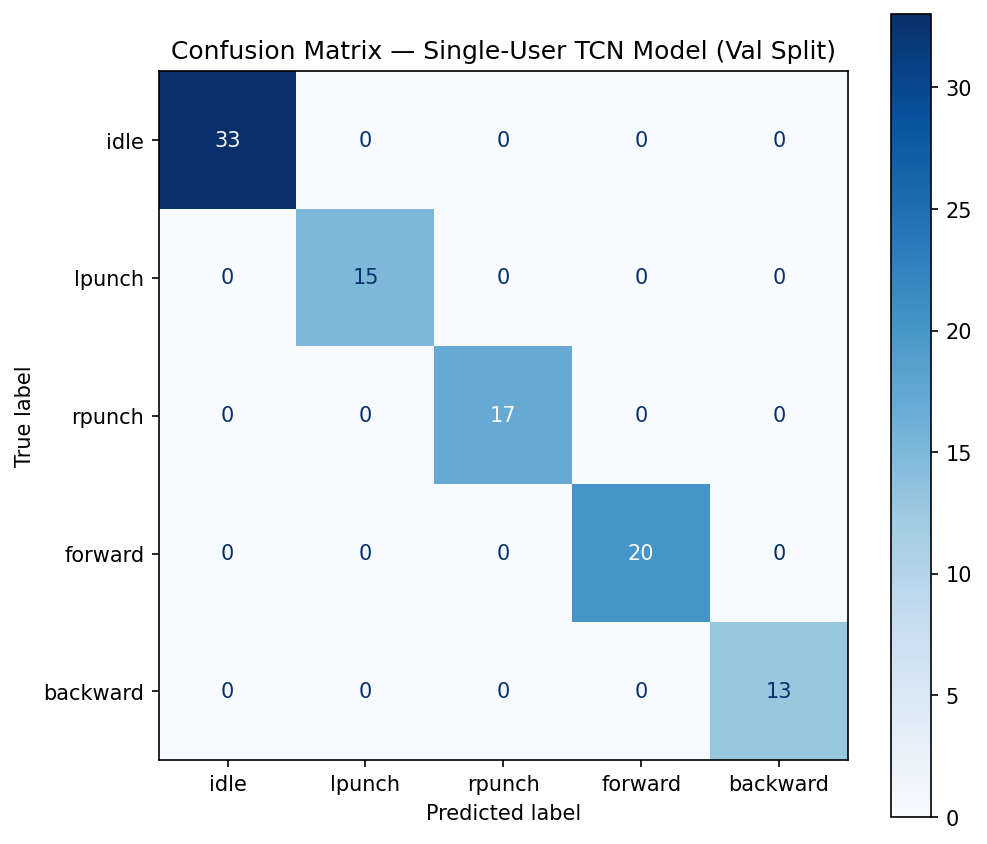

In [4]:
confusion = np.array([
    [33, 0, 0, 0, 0],
    [0, 15, 0, 0, 0],
    [0, 0, 17, 0, 0],
    [0, 0, 0, 20, 0],
    [0, 0, 0, 0, 13],
])
val_total = int(confusion.sum())
tcn_acc = np.trace(confusion) / val_total
print(f"Validation windows: {val_total}")
print(f"TCN validation accuracy: {tcn_acc:.2%}")
display(pd.DataFrame(confusion, index=ACTION_NAMES, columns=ACTION_NAMES))

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion, display_labels=ACTION_NAMES)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=True)
ax.set_title("Confusion Matrix — Single-User TCN Model (Val Split)")
plt.tight_layout()
save_report_figure(fig, "confusion_matrix.png")
plt.show()

## 4. Rule-Based vs TCN Comparison

The rule-based detector reached 36.73% on the same validation split. The TCN reached 100.00% on this controlled split.

Rule-based validation accuracy: 36.73%
TCN validation accuracy:        100.00%


,class,rule_based_accuracy,tcn_accuracy
0,idle,1.000000,1.0
1,lpunch,0.000000,1.0
2,rpunch,0.000000,1.0
3,forward,0.150000,1.0
4,backward,0.000000,1.0
5,overall,0.367347,1.0


Saved: results/figures/rule_vs_tcn.png
Saved: final_site/assets/rule_vs_tcn.png


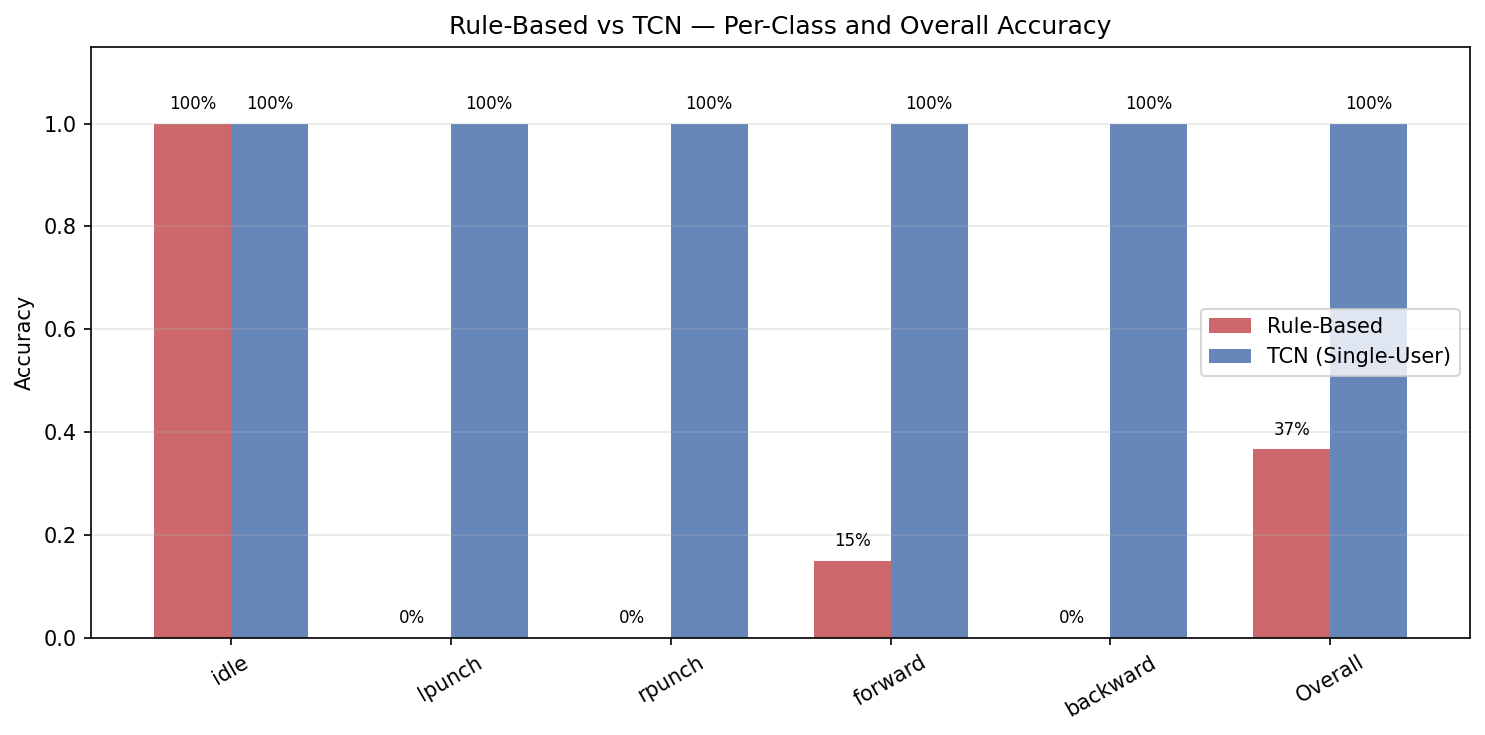

In [5]:
support = confusion.sum(axis=1)
rule_correct = np.array([33, 0, 0, 3, 0])
tcn_correct = np.diag(confusion)
rule_per_class = rule_correct / support
tcn_per_class = tcn_correct / support
rule_overall = rule_correct.sum() / support.sum()
tcn_overall = tcn_correct.sum() / support.sum()

comparison = pd.DataFrame({
    "class": ACTION_NAMES + ["overall"],
    "rule_based_accuracy": list(rule_per_class) + [rule_overall],
    "tcn_accuracy": list(tcn_per_class) + [tcn_overall],
})
print(f"Rule-based validation accuracy: {rule_overall:.2%}")
print(f"TCN validation accuracy:        {tcn_overall:.2%}")
display(comparison)

labels = ACTION_NAMES + ["Overall"]
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, comparison["rule_based_accuracy"], width, label="Rule-Based", color="#C44E52", alpha=0.85)
bars2 = ax.bar(x + width/2, comparison["tcn_accuracy"], width, label="TCN (Single-User)", color="#4C72B0", alpha=0.85)
ax.set_ylabel("Accuracy")
ax.set_title("Rule-Based vs TCN — Per-Class and Overall Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bars in (bars1, bars2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.0%}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
save_report_figure(fig, "rule_vs_tcn.png")
plt.show()

## 5. Hyperparameter Experiment Results

These bars come directly from `results/experiment_log.csv`. The main point is that every logged TCN configuration fit this small dataset, so the sweep is not strong evidence of broad generalization.

,run_id,model,optimizer,learning_rate,batch_size,weight_decay,window_size,epochs,train_accuracy,validation_accuracy,training_time_s,notes
0,LR-A,ActionTCN,adam,0.0010,16.0,0.0000,20,60.0,0.9949,1.0000,27.1,NaN
1,LR-B,ActionTCN,adam,0.0003,16.0,0.0000,20,60.0,0.9899,1.0000,27.1,NaN
2,LR-C,ActionTCN,adam,0.0001,16.0,0.0000,20,60.0,0.9924,1.0000,27.1,NaN
3,OPT-B,ActionTCN,adamw,0.0010,16.0,0.0001,20,60.0,0.9975,1.0000,27.1,NaN
4,OPT-C,ActionTCN,adamw,0.0003,16.0,0.0001,20,60.0,1.0000,1.0000,28.0,NaN
5,BS-A,ActionTCN,adam,0.0010,8.0,0.0000,20,60.0,0.9949,1.0000,13.8,NaN
6,BS-C,ActionTCN,adam,0.0010,32.0,0.0000,20,60.0,1.0000,1.0000,23.9,NaN
7,WIN-A,ActionTCN,adam,0.0010,16.0,0.0000,10,60.0,0.9713,1.0000,22.8,NaN
8,WIN-C,ActionTCN,adam,0.0010,16.0,0.0000,30,60.0,1.0000,1.0000,33.4,NaN
9,RULE,RuleBased,NaN,NaN,NaN,NaN,20,NaN,NaN,0.3673,0.0,offline eval on val split


Training runs used in sweep: 9
Validation accuracies: [np.float64(1.0)]


Saved: results/figures/hyperparameter_sweep.png
Saved: final_site/assets/hyperparameter_sweep.png


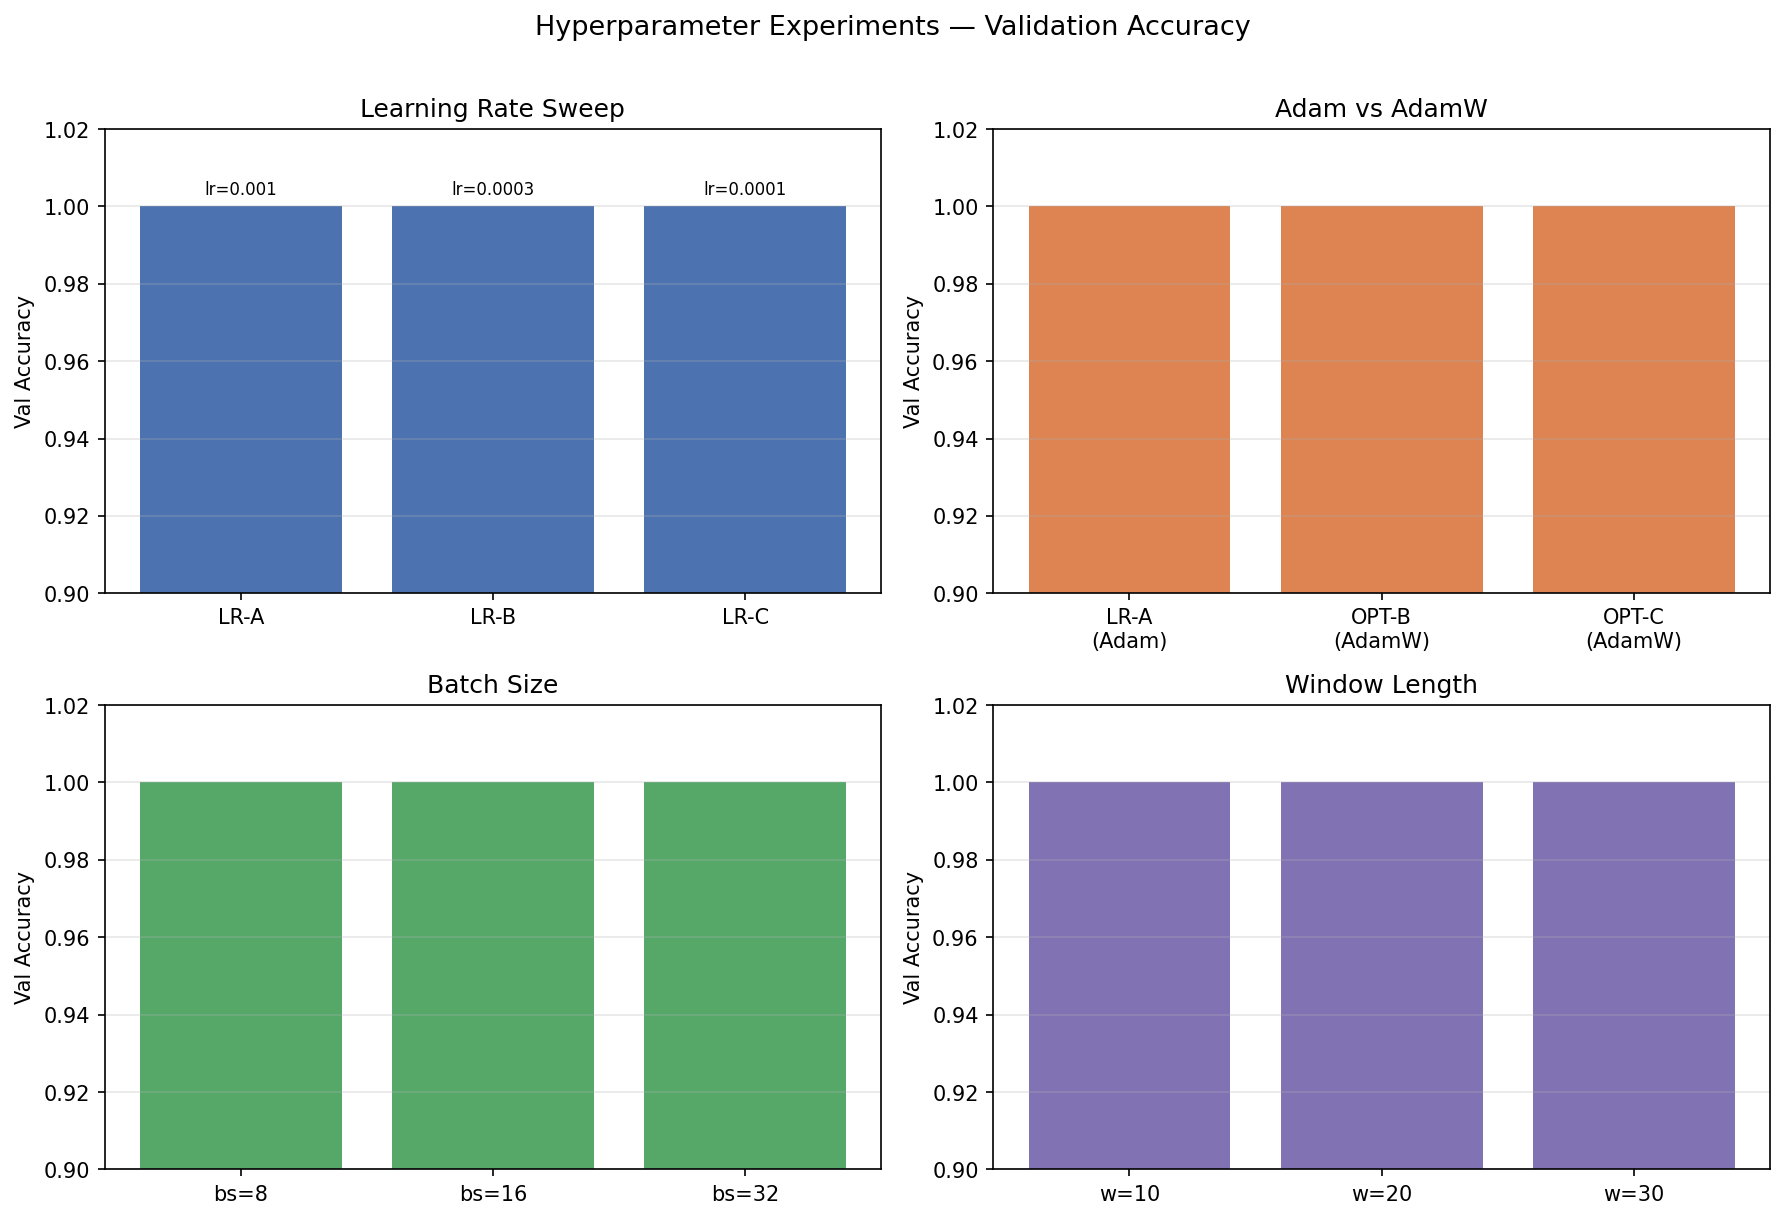

In [6]:
csv_path = PROJECT_ROOT / "results" / "experiment_log.csv"
df = pd.read_csv(csv_path)
display(df)

train_df = df[df["model"] == "ActionTCN"].copy()
train_df = train_df[train_df["run_id"].str.startswith(("LR-", "OPT-", "BS-", "WIN-"))].copy()
print("Training runs used in sweep:", len(train_df))
print("Validation accuracies:", sorted(train_df["validation_accuracy"].unique()))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

lr_df = train_df[train_df["run_id"].str.startswith("LR-")]
axes[0, 0].bar(lr_df["run_id"], lr_df["validation_accuracy"].astype(float), color="#4C72B0")
axes[0, 0].set_title("Learning Rate Sweep")
axes[0, 0].set_ylabel("Val Accuracy")
axes[0, 0].set_ylim(0.9, 1.02)
for pos, (_, row) in enumerate(lr_df.iterrows()):
    axes[0, 0].text(pos, float(row["validation_accuracy"]) + 0.003,
                    f"lr={row['learning_rate']}", ha="center", fontsize=8)

opt_rows = [train_df[train_df["run_id"] == rid].iloc[0] for rid in ["LR-A", "OPT-B", "OPT-C"]]
axes[0, 1].bar(["LR-A\n(Adam)", "OPT-B\n(AdamW)", "OPT-C\n(AdamW)"],
               [float(r["validation_accuracy"]) for r in opt_rows], color="#DD8452")
axes[0, 1].set_title("Adam vs AdamW")
axes[0, 1].set_ylabel("Val Accuracy")
axes[0, 1].set_ylim(0.9, 1.02)

bs_rows = [train_df[train_df["run_id"] == rid].iloc[0] for rid in ["BS-A", "LR-A", "BS-C"]]
axes[1, 0].bar([f"bs={int(r['batch_size'])}" for r in bs_rows],
               [float(r["validation_accuracy"]) for r in bs_rows], color="#55A868")
axes[1, 0].set_title("Batch Size")
axes[1, 0].set_ylabel("Val Accuracy")
axes[1, 0].set_ylim(0.9, 1.02)

win_rows = [train_df[train_df["run_id"] == rid].iloc[0] for rid in ["WIN-A", "LR-A", "WIN-C"]]
axes[1, 1].bar([f"w={int(r['window_size'])}" for r in win_rows],
               [float(r["validation_accuracy"]) for r in win_rows], color="#8172B3")
axes[1, 1].set_title("Window Length")
axes[1, 1].set_ylabel("Val Accuracy")
axes[1, 1].set_ylim(0.9, 1.02)

for ax in axes.flat:
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Hyperparameter Experiments — Validation Accuracy", fontsize=13, y=1.01)
plt.tight_layout()
save_report_figure(fig, "hyperparameter_sweep.png")
plt.show()

## 6. Resource Summary

This summarizes the checked-in model and runtime setup used by the final project.

,Resource,Value
0,Model architecture,"TCN, 2 temporal blocks, 64 channels, kernel_si..."
1,Parameters,"93,701"
2,Model file size,379 KB
3,Input dimensions,"(20, 81) = 20 frames x (27 pos + 27 vel + 27 acc)"
4,Upper-body joints,"9 (nose, shoulders, elbows, wrists, hips)"
5,Output classes,"5 (idle, lpunch, rpunch, forward, backward)"
6,Training data,"8 npz recordings, 494 windows"
7,Training time,13.8-33.4 s across logged runs
8,TCN inference,Sub-millisecond to low-millisecond per window ...
9,Pose estimation model,"MediaPipe Pose Landmarker Lite, 5.5 MB"


Saved: results/figures/resource_summary.png
Saved: final_site/assets/resource_summary.png


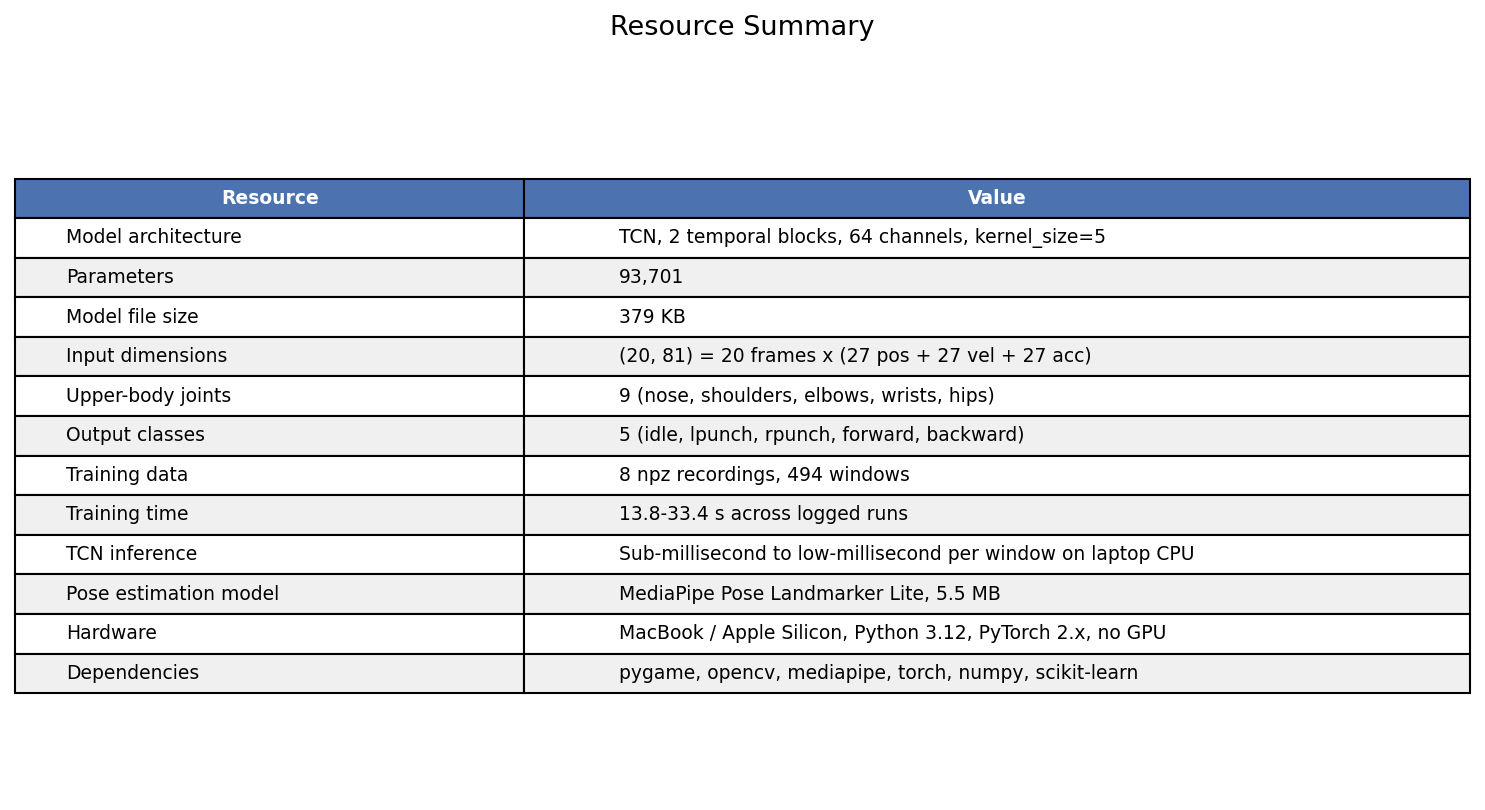

In [7]:
model_path = PROJECT_ROOT / "motion" / "models" / "action_personal.pt"
pose_path = PROJECT_ROOT / "motion" / "models" / "pose_landmarker_lite.task"
model_size_kb = model_path.stat().st_size / 1024 if model_path.exists() else 0
pose_size_mb = pose_path.stat().st_size / (1024 * 1024) if pose_path.exists() else 0

resources = {
    "Model architecture": "TCN, 2 temporal blocks, 64 channels, kernel_size=5",
    "Parameters": "93,701",
    "Model file size": f"{model_size_kb:.0f} KB",
    "Input dimensions": "(20, 81) = 20 frames x (27 pos + 27 vel + 27 acc)",
    "Upper-body joints": "9 (nose, shoulders, elbows, wrists, hips)",
    "Output classes": "5 (idle, lpunch, rpunch, forward, backward)",
    "Training data": "8 npz recordings, 494 windows",
    "Training time": "13.8-33.4 s across logged runs",
    "TCN inference": "Sub-millisecond to low-millisecond per window on laptop CPU",
    "Pose estimation model": f"MediaPipe Pose Landmarker Lite, {pose_size_mb:.1f} MB",
    "Hardware": "MacBook / Apple Silicon, Python 3.12, PyTorch 2.x, no GPU",
    "Dependencies": "pygame, opencv, mediapipe, torch, numpy, scikit-learn",
}
resource_df = pd.DataFrame(resources.items(), columns=["Resource", "Value"])
display(resource_df)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axis("off")
table = ax.table(
    cellText=resource_df.values,
    colLabels=resource_df.columns,
    cellLoc="left",
    loc="center",
    colWidths=[0.35, 0.65],
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#4C72B0")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#f0f0f0")
ax.set_title("Resource Summary", fontsize=13, pad=20)
plt.tight_layout()
save_report_figure(fig, "resource_summary.png")
plt.show()

## 7. System Pipeline Diagram

Saved: results/figures/system_pipeline.png
Saved: final_site/assets/system_pipeline.png


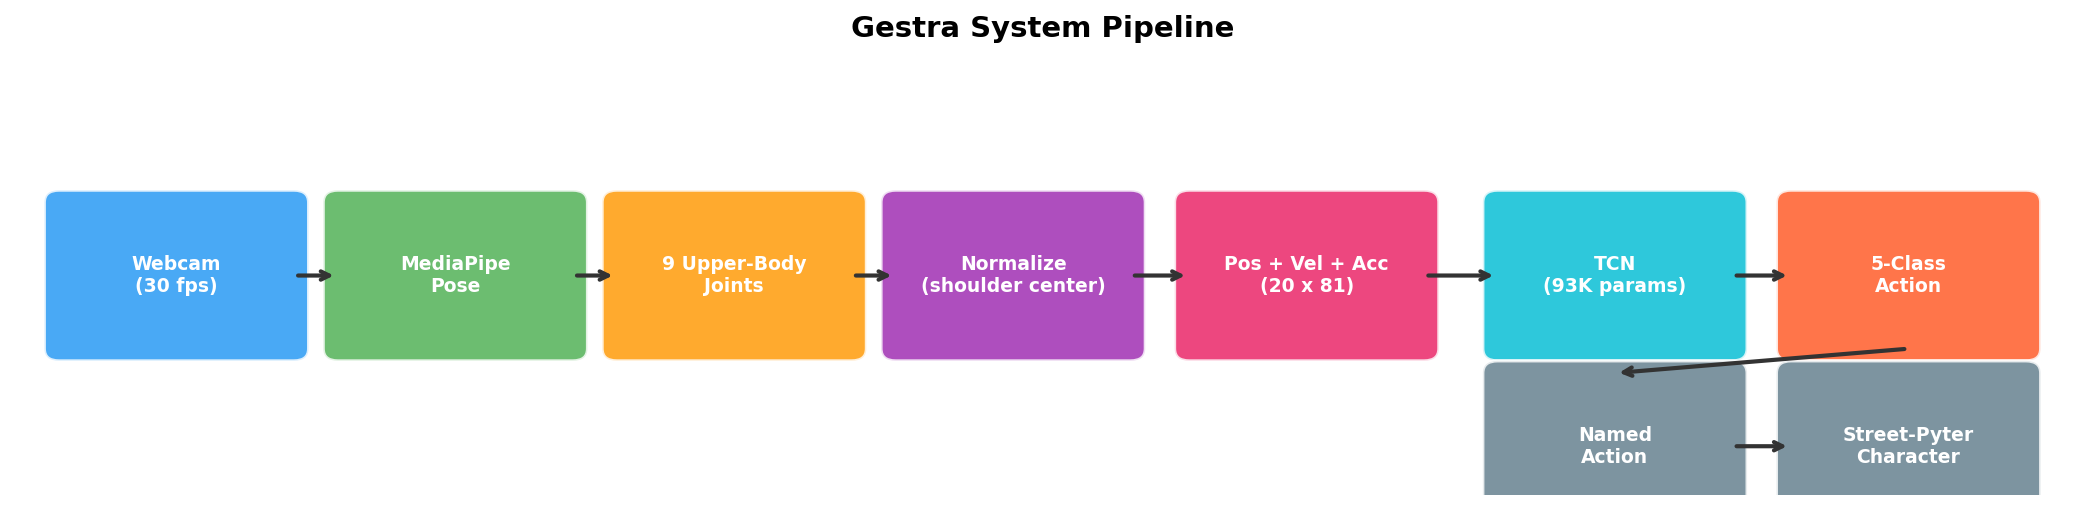

In [8]:
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 3.5)
ax.axis("off")

boxes = [
    (0.3, 1.2, "Webcam\n(30 fps)"),
    (2.2, 1.2, "MediaPipe\nPose"),
    (4.1, 1.2, "9 Upper-Body\nJoints"),
    (6.0, 1.2, "Normalize\n(shoulder center)"),
    (8.0, 1.2, "Pos + Vel + Acc\n(20 x 81)"),
    (10.1, 1.2, "TCN\n(93K params)"),
    (12.1, 1.2, "5-Class\nAction"),
]
box_w, box_h = 1.6, 1.2
colors_pipe = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#E91E63", "#00BCD4", "#FF5722"]
for i, (x0, y0, text) in enumerate(boxes):
    rect = mpatches.FancyBboxPatch((x0, y0), box_w, box_h, boxstyle="round,pad=0.1",
                                   facecolor=colors_pipe[i], alpha=0.82,
                                   edgecolor="white", linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x0 + box_w/2, y0 + box_h/2, text, ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")
    if i > 0:
        prev_x = boxes[i-1][0]
        ax.annotate("", xy=(x0, y0 + box_h/2), xytext=(prev_x + box_w, y0 + box_h/2),
                    arrowprops=dict(arrowstyle="->", color="#333", lw=2))

game_boxes = [(10.1, -0.2, "Named\nAction"), (12.1, -0.2, "Street-Pyter\nCharacter")]
for x0, y0, text in game_boxes:
    rect = mpatches.FancyBboxPatch((x0, y0), box_w, box_h, boxstyle="round,pad=0.1",
                                   facecolor="#607D8B", alpha=0.82,
                                   edgecolor="white", linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x0 + box_w/2, y0 + box_h/2, text, ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")
ax.annotate("", xy=(10.1 + box_w/2, -0.2 + box_h), xytext=(12.1 + box_w/2, 1.2),
            arrowprops=dict(arrowstyle="->", color="#333", lw=2))
ax.annotate("", xy=(12.1, -0.2 + box_h/2), xytext=(10.1 + box_w, -0.2 + box_h/2),
            arrowprops=dict(arrowstyle="->", color="#333", lw=2))
ax.set_title("Gestra System Pipeline", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
save_report_figure(fig, "system_pipeline.png")
plt.show()

## Final Check

In [9]:
expected = [
    "dataset_summary.png",
    "training_curve.png",
    "confusion_matrix.png",
    "rule_vs_tcn.png",
    "hyperparameter_sweep.png",
    "resource_summary.png",
    "system_pipeline.png",
]
check = pd.DataFrame({
    "figure": expected,
    "results/figures": [(RESULTS_DIR / f).exists() for f in expected],
    "final_site/assets": [(ASSETS_DIR / f).exists() for f in expected],
})
display(check)
assert check["results/figures"].all()
assert check["final_site/assets"].all()
print("All report figures were displayed above and saved to both output directories.")

,figure,results/figures,final_site/assets
0,dataset_summary.png,True,True
1,training_curve.png,True,True
2,confusion_matrix.png,True,True
3,rule_vs_tcn.png,True,True
4,hyperparameter_sweep.png,True,True
5,resource_summary.png,True,True
6,system_pipeline.png,True,True


All report figures were displayed above and saved to both output directories.
